# Medical Cost Personal Datasets
## Insurance Forecast by using Linear Regression

### - Carga de datos

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [37]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


Las 7 columnas tiene completos los datos en las 1338 filas.

In [38]:
columnas_categoricas = df.select_dtypes(include=['object', 'string']).columns

for col in columnas_categoricas:
    valores = df[col].unique()
    print(f"-> {col.upper()}: {list(valores)}")

-> SEX: ['female', 'male']
-> SMOKER: ['yes', 'no']
-> REGION: ['southwest', 'southeast', 'northwest', 'northeast']


# Descripción de las variables
### Variables Numéricas (Continuas y Discretas)
age (int64): Edad del beneficiario principal. Es un factor clave, ya que el riesgo médico suele subir con los años.


bmi (float64): Índice de Masa Corporal (kg/m2). Es una medida de la relación entre peso y altura; valores altos suelen asociarse a mayores riesgos de salud.

children (int64): Número de hijos o dependientes cubiertos por el seguro médico.

charges (float64): Variable Objetivo (Target). Es el costo de la prima del seguro facturado por el sistema. Es lo que queremos predecir.

### Variables Categóricas (Texto)
sex (str): Género del asegurado (male, female).

smoker (str): Indica si la persona fuma o no (yes, no). Históricamente, esta es la variable con mayor impacto en el costo final.

region (str): Zona de residencia del beneficiario en EE. UU. (northeast, northwest, southeast, southwest).

# Análisis de variables

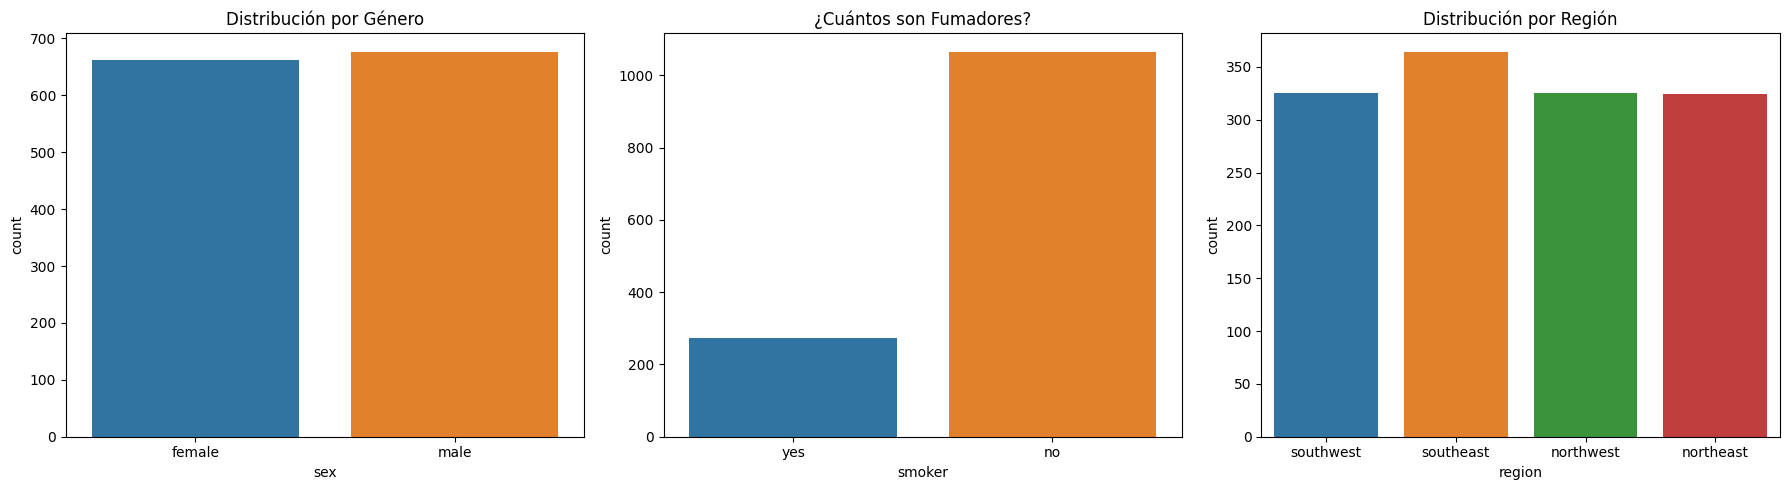

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Distribución por Sexo
sns.countplot(data=df, x='sex', ax=axes[0], hue='sex', legend=False)
axes[0].set_title('Distribución por Género')

# Gráfico 2: Distribución por Fumadores (Variable Crítica)
sns.countplot(data=df, x='smoker', ax=axes[1], hue='smoker', legend=False)
axes[1].set_title('¿Cuántos son Fumadores?')

# Gráfico 3: Distribución por Región
sns.countplot(data=df, x='region', ax=axes[2], hue='region', legend=False)
axes[2].set_title('Distribución por Región')

plt.tight_layout()
plt.show()

En las variables categóricas, el género y las regiones están muy balanceadas, en cambio dominan los no fumadores en la muestra.

In [41]:
# Conversión de categóricas en numéricas con drop_first=True para evitar redundancia
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Verificamos cómo quedaron las columnas
print(df.columns)

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')


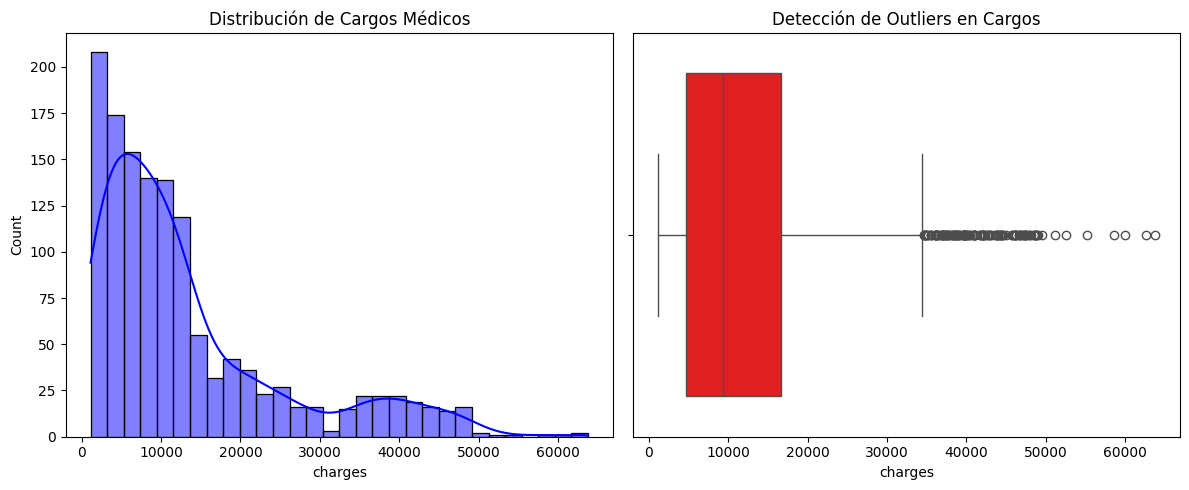

In [42]:
plt.figure(figsize=(12, 5))

# Histograma con curva de densidad
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribución de Cargos Médicos')

# Boxplot para detectar outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['charges'], color='red')
plt.title('Detección de Outliers en Cargos')

plt.tight_layout()
plt.show()


In [43]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


En las variables numéricas, se observa que los valores no poseen outliers notorios y distribuciones normales. En el caso de charges se nota asimetría hacia mayores valores.

In [44]:
print(df.corr()['charges'].sort_values(ascending=False))

charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


La correlación con si la persona es fumadora es muy marcada, luego en menor medida está la edad y la masa corporal.

De manera muy leve, se puede decir que la región sudeste tiene los cargos más altos al igual que tiende a ser más alto con más hijos y ser hombre.

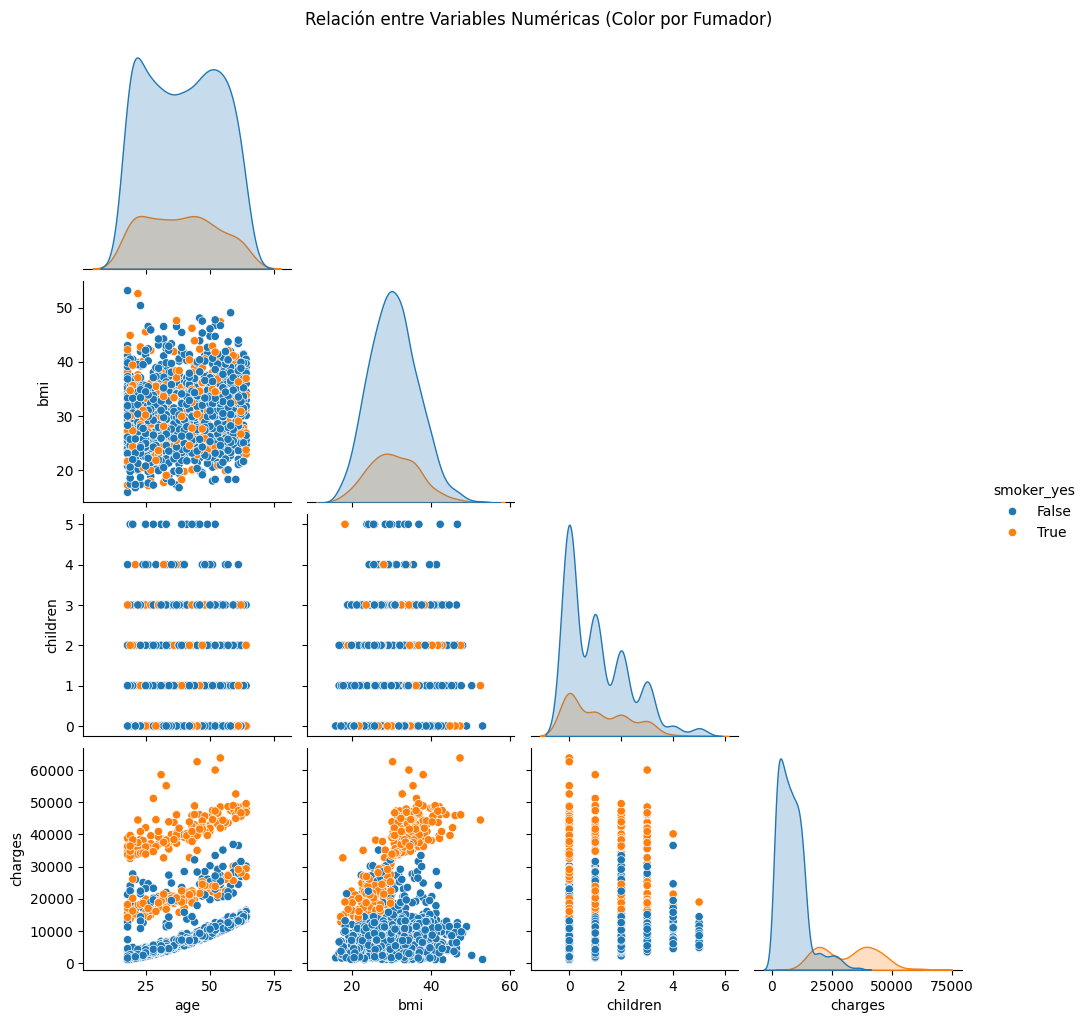

In [45]:
col_color = 'smoker_yes' if 'smoker_yes' in df.columns else 'smoker'

cols_numericas = ['age', 'bmi', 'children', 'charges', col_color]

# 2. Creamos el pairplot
sns.pairplot(df[cols_numericas], hue=col_color, corner=True)

plt.suptitle('Relación entre Variables Numéricas (Color por Fumador)', y=1.02)
plt.show()

Se vuelve a notar la marcada diferencia en costos si la persona es fumadora, en menor medida también se ven diferencias en bmi y age.

# - Separación de datos

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [48]:
X = df.drop('charges', axis=1)
y = df['charges']

# División Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# - Modelo de regresión lineal vs. Lasso

In [49]:
# Regresión Lineal Base
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Lasso Base (alpha=1.0 por defecto)
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

print(f"R2 Lineal: {r2_score(y_test, pred_lr):.4f}")
print(f"R2 Lasso (Base): {r2_score(y_test, pred_lasso):.4f}")

R2 Lineal: 0.7836
R2 Lasso (Base): 0.7835


La Regresión Lineal y el Lasso con Alpha pequeño dan resultados muy parecidos porque no hay cientos de variables redundantes.



# - Evolución del R2 según Alpha (Lasso)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.994e+10, tolerance: 1.544e+07
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_co

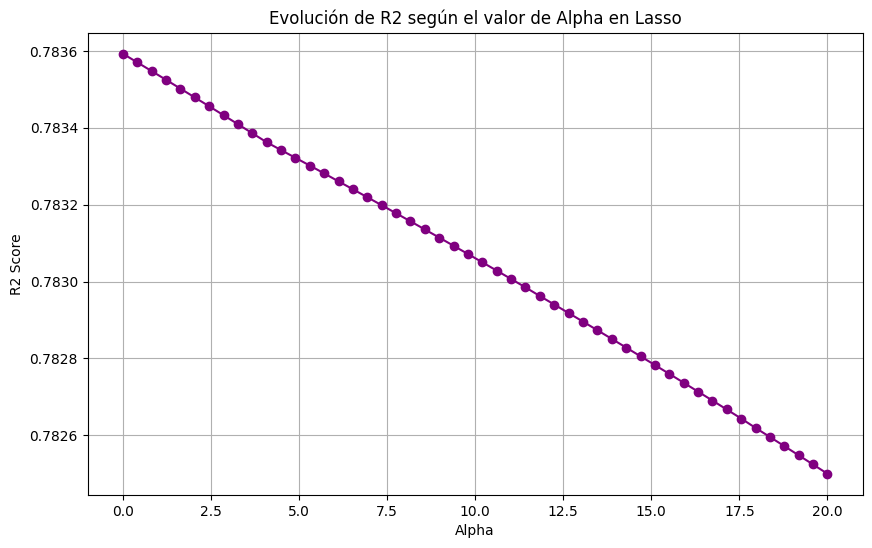

In [50]:
alphas = np.linspace(0, 20, 50)
r2_values = []

for a in alphas:
    # Usamos un try-except por si alpha=0 da problemas de convergencia (equivale a OLS)
    model_l = Lasso(alpha=a)
    model_l.fit(X_train, y_train)
    r2_values.append(r2_score(y_test, model_l.predict(X_test)))

# Dibujar diagrama de líneas
plt.figure(figsize=(10, 6))
plt.plot(alphas, r2_values, marker='o', color='purple')
plt.title('Evolución de R2 según el valor de Alpha en Lasso')
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.grid(True)
plt.show()

Gráfico: Verás si el R2 sube, baja o se mantiene estable. Si el R2 baja rápido al subir Alpha, significa que todas tus variables actuales son importantes y Lasso las está "apagando" demasiado pronto.

# - Escalamiento y comparación con base

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score

scaler = StandardScaler()

# 2. Ajustamos con X_train y transformamos ambos (X_train y X_test)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Regresión Lineal (los resultados de R2 no cambian con el escalado, pero es buena práctica)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
r2_lr = r2_score(y_test, lr.predict(X_test_scaled))

# 4. Lasso Base (Alpha = 1.0)
lasso_base = Lasso(alpha=1.0)
lasso_base.fit(X_train_scaled, y_train)
r2_lasso = r2_score(y_test, lasso_base.predict(X_test_scaled))

print(f"R2 Lineal (Escalado): {r2_lr:.4f}")
print(f"R2 Lasso (Alpha=1.0, Escalado): {r2_lasso:.4f}")

R2 Lineal (Escalado): 0.7836
R2 Lasso (Alpha=1.0, Escalado): 0.7836


# - Experimento de Alpha (0.0 a 20)

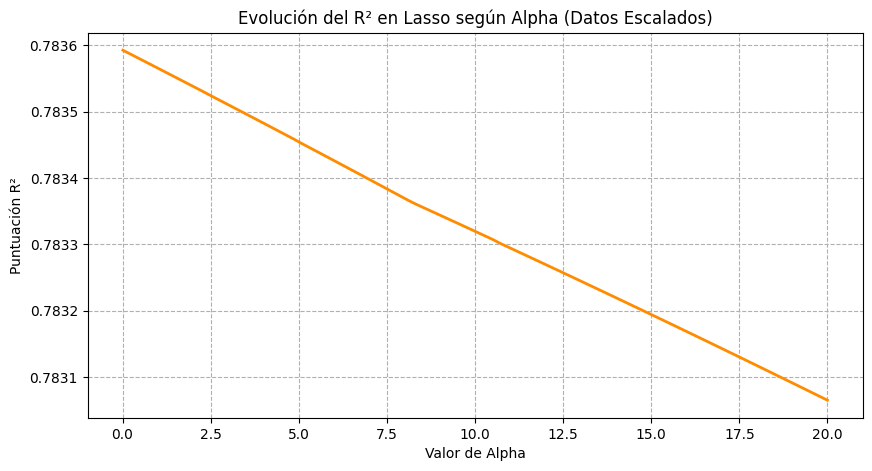

In [52]:
alphas = np.linspace(0.01, 20, 100) # Empezamos en 0.01 para evitar avisos de convergencia
r2_list = []

for a in alphas:
    m = Lasso(alpha=a)
    m.fit(X_train_scaled, y_train)
    r2_list.append(r2_score(y_test, m.predict(X_test_scaled)))

# Graficamos el resultado
plt.figure(figsize=(10, 5))
plt.plot(alphas, r2_list, color='darkorange', linewidth=2)
plt.title('Evolución del R² en Lasso según Alpha (Datos Escalados)')
plt.xlabel('Valor de Alpha')
plt.ylabel('Puntuación R²')
plt.grid(True, linestyle='--')
plt.show()

La línea ahora se ha aplanado más por lo que una pequeña penalización no las "apaga".
El valor óptimo de Alpha es donde el R² sea más alto.

# - Probando Polynomial Feature

Como vimos en el EDA, los cargos no suben de forma lineal simple; se disparan cuando se combinan factores (como Fumador + BMI alto). PolynomialFeatures crea esta combinación.

In [53]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# 1. Creamos el generador de interacciones (grado 2 es suficiente y no satura)
poly = PolynomialFeatures(degree=2, include_bias=False)

# 2. Transformamos nuestras X (usaremos las X originales antes del escalado previo)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# 3. ¡IMPORTANTE! Re-escalar después de crear polinomios (los valores crecen mucho)
scaler_poly = StandardScaler()
X_poly_train_scaled = scaler_poly.fit_transform(X_poly_train)
X_poly_test_scaled = scaler_poly.transform(X_poly_test)

# 4. Entrenamos Lasso sobre los datos polinómicos
# Usamos un alpha pequeño (ej. 10) porque ahora tenemos MUCHAS más columnas
model_poly = Lasso(alpha=10, max_iter=10000)
model_poly.fit(X_poly_train_scaled, y_train)

# 5. Resultados
pred_poly = model_poly.predict(X_poly_test_scaled)
print(f"R2 con Interacciones Polinómicas: {r2_score(y_test, pred_poly):.4f}")

R2 con Interacciones Polinómicas: 0.8674


Así se alcanza un valor superior.